# Projet pratique - S6 : Structures de donnees Python
## Digitaliser les recoltes du reseau cooperatif AgriSuds

**Akieni Academy** a ete sollicitee par **AgriSuds**, un reseau de cooperatives agricoles
actif dans plusieurs pays d'Afrique (Congo-Brazzaville, Cote d'Ivoire, Cameroun, Senegal,
Togo). Chaque antenne locale enregistre ses recoltes : identite du producteur, culture,
quantite recoltee (kg), prix de vente au kg (FCFA) et anciennete de la recolte (en jours).

**Le besoin exprime par AgriSuds** : des reponses claires, calculees automatiquement en
Python, a des questions concretes que se posent les responsables de la cooperative :
- Quel est le chiffre d'affaires total genere par les recoltes ?
- Quelle quantite a ete recoltee pour telle culture (cacao, cafe, manioc...) ?
- Quelles sont les cultures et antennes actives dans les donnees ?
- Quelle fourchette de prix a ete pratiquee pour une culture ?
- Quelle est la fiche complete d'un producteur donne ?
- Qui sont les producteurs les plus productifs ?
- Quelles recoltes sont recentes, pour anticiper les livraisons ?

**Notions mobilisees dans ce projet** : variables, structures conditionnelles, boucles,
fonctions, et les structures de donnees vues en cours : listes, tuples, dictionnaires,
sets.

**Consigne generale** : completez chaque fonction a l'endroit indique par `# TODO`, puis
executez immediatement la cellule de test juste en dessous pour verifier votre travail
avant de passer a la fonction suivante.


---
## 1. Les donnees de recoltes *(fournies - ne pas modifier)*

Les recoltes du mois sont deja chargees ci-dessous sous forme de **7 listes paralleles** :
la recolte d'indice `i` est decrite par l'element d'indice `i` dans chacune des listes
`IDS`, `AGRICULTEURS`, `ANTENNES`, `CULTURES`, `QUANTITES_KG`, `PRIX_KG_FCFA` et
`JOURS_ECOULE` (anciennete de la recolte, en nombre de jours).

Attention : environ 8% des recoltes ont une **quantite manquante** (valeur `None`), pour
simuler un oubli de saisie sur le terrain. Vos fonctions doivent gerer ce cas sans planter.


In [1]:
# Donnees de recoltes AgriSuds (fournies - ne pas modifier)
# 7 listes paralleles : la recolte d'indice i est decrite par l'element d'indice i
# dans CHACUNE des listes ci-dessous.

IDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]

AGRICULTEURS = ['Fatou Kouassi', 'Nadege Diop', 'Aminata Mokoko', 'Herve Bationo', 'Serge Ngoma', 'Olivier Diallo', 'Serge Ngoma', 'Olivier Diallo', 'Paul Kouassi', 'Herve Samba', 'Serge Bikindou', 'Aminata Mokoko', 'Olivier Diallo', 'Sandra Loubota', 'Serge Mokoko', 'Prisca Mabiala', 'Olivier Diallo', 'Moise Ngoma', 'Herve Samba', 'Olivier Diallo', 'Serge Bikindou', 'Sandra Loubota', 'Paul Kouassi', 'Aminata Ngoma', 'Aminata Mokoko', 'Larissa Diop', 'Aminata Bationo', 'Serge Nzila', 'Grace Bikindou', 'Aminata Mokoko', 'Herve Bationo', 'Nadege Diop', 'Blaise Malonga', 'Moise Ngoma', 'Aminata Bationo', 'Nadege Diop', 'Paul Kouassi', 'Blaise Malonga', 'Chantal Kouassi', 'Serge Mokoko', 'Serge Nzila', 'Fatou Kouassi', 'Larissa Diop', 'Herve Samba', 'Marie Bikindou', 'Blaise Malonga', 'Grace Kabila', 'Larissa Diop', 'Serge Bikindou', 'Larissa Diop']

ANTENNES = ['Kaolack', 'Divo', 'Divo', 'Kaolack', 'Kpalime', 'Owando', 'Divo', 'Bafoussam', 'Bafoussam', 'Owando', 'Kpalime', 'Kpalime', 'Divo', 'Bafoussam', 'Divo', 'Owando', 'Kaolack', 'Kaolack', 'Bafoussam', 'Bafoussam', 'Bafoussam', 'Kpalime', 'Divo', 'Bafoussam', 'Owando', 'Divo', 'Owando', 'Kpalime', 'Bafoussam', 'Kpalime', 'Kpalime', 'Divo', 'Kaolack', 'Divo', 'Kpalime', 'Kaolack', 'Divo', 'Owando', 'Divo', 'Bafoussam', 'Owando', 'Kaolack', 'Owando', 'Bafoussam', 'Owando', 'Kpalime', 'Kaolack', 'Kaolack', 'Owando', 'Divo']

CULTURES = ['Mais', 'Manioc', 'Riz', 'Huile de palme', 'Cafe', 'Cafe', 'Arachide', 'Banane plantain', 'Cafe', 'Arachide', 'Mais', 'Banane plantain', 'Cafe', 'Arachide', 'Arachide', 'Cacao', 'Mais', 'Banane plantain', 'Mais', 'Cacao', 'Banane plantain', 'Arachide', 'Arachide', 'Mais', 'Riz', 'Cacao', 'Banane plantain', 'Manioc', 'Huile de palme', 'Banane plantain', 'Cacao', 'Cafe', 'Huile de palme', 'Huile de palme', 'Cafe', 'Arachide', 'Mais', 'Huile de palme', 'Cafe', 'Manioc', 'Mais', 'Huile de palme', 'Huile de palme', 'Banane plantain', 'Manioc', 'Arachide', 'Banane plantain', 'Banane plantain', 'Riz', 'Cacao']

QUANTITES_KG = [284.9, 138.2, 20.9, 172.8, 84.7, None, 274.1, 189.0, 70.9, 259.5, 153.4, 54.4, 70.2, 150.9, None, 313.3, 264.8, 80.6, 209.0, None, 271.6, 28.8, 308.3, 81.4, 168.3, 58.9, 86.0, 283.1, 211.2, 57.5, 287.3, 125.0, 206.0, 36.4, None, 86.6, 165.7, 29.3, 213.7, None, 172.5, 182.5, 265.1, 79.3, 124.7, 85.6, None, 119.9, 270.9, 128.5]

PRIX_KG_FCFA = [222, 165, 337, 767, 1601, 1697, 669, 226, 1706, 707, 175, 294, 2141, 622, 583, 1285, 235, 297, 228, 1714, 227, 636, 604, 172, 344, 1323, 214, 162, 632, 277, 1709, 1550, 732, 660, 1945, 680, 222, 818, 1908, 128, 217, 783, 599, 231, 167, 696, 215, 239, 298, 1748]

JOURS_ECOULE = [20, 53, 70, 37, 112, 99, 86, 89, 114, 10, 43, 67, 119, 86, 32, 65, 55, 29, 51, 80, 111, 23, 70, 23, 25, 75, 74, 49, 5, 67, 87, 13, 87, 119, 94, 96, 48, 80, 88, 34, 59, 39, 57, 74, 77, 114, 62, 40, 15, 50]

# Quelques constantes utiles (dictionnaires et listes deja construits)
ANTENNES_DISPONIBLES = ["Owando", "Divo", "Bafoussam", "Kaolack", "Kpalime"]
PAYS_ANTENNE = {
    "Owando": "Congo-Brazzaville",
    "Divo": "Cote d'Ivoire",
    "Bafoussam": "Cameroun",
    "Kaolack": "Senegal",
    "Kpalime": "Togo",
}
CULTURES_DISPONIBLES = ["Cacao", "Cafe", "Manioc", "Mais", "Arachide", "Riz", "Banane plantain", "Huile de palme"]
PRIX_MOYEN_KG = {
    "Cacao": 1500, "Cafe": 1800, "Manioc": 150, "Mais": 200,
    "Arachide": 600, "Riz": 350, "Banane plantain": 250, "Huile de palme": 700,
}

print("Nombre de recoltes chargees :", len(IDS))


Nombre de recoltes chargees : 50


---
## 2. Variables mises a votre disposition *(fourni)*

Executez la cellule ci-dessous pour verifier que tout est bien charge : `ANTENNES_DISPONIBLES`,
`PAYS_ANTENNE`, `CULTURES_DISPONIBLES`, `PRIX_MOYEN_KG`.


In [2]:
print("Antennes disponibles :", ANTENNES_DISPONIBLES)
print("Pays de l'antenne Owando :", PAYS_ANTENNE["Owando"])
print("Cultures disponibles :", CULTURES_DISPONIBLES)
print("Prix moyen du cacao (FCFA/kg) :", PRIX_MOYEN_KG["Cacao"])


Antennes disponibles : ['Owando', 'Divo', 'Bafoussam', 'Kaolack', 'Kpalime']
Pays de l'antenne Owando : Congo-Brazzaville
Cultures disponibles : ['Cacao', 'Cafe', 'Manioc', 'Mais', 'Arachide', 'Riz', 'Banane plantain', 'Huile de palme']
Prix moyen du cacao (FCFA/kg) : 1500


---
## 3. A vous de jouer - Niveau Debutant

Ces 3 fonctions ne manipulent que des **variables**, des **boucles** et des **conditions**.
Completez chaque fonction puis executez tout de suite la cellule de test juste en dessous.


In [3]:
def chiffre_affaires_total(quantites, prix):
    """
    Calcule le chiffre d'affaires total de toutes les récoltes.
    Ignore les quantités manquantes (None).
    """
    total = 0
    for i in range(len(quantites)):
        if quantites[i] is None:
            continue
        total += quantites[i] * prix[i]
    return round(total, 2)


In [4]:
# Test de chiffre_affaires_total
resultat = chiffre_affaires_total(QUANTITES_KG, PRIX_KG_FCFA)
print("Chiffre d'affaires total (FCFA) :", resultat)


Chiffre d'affaires total (FCFA) : 4503616.6


In [6]:
def quantite_totale_culture(cultures, quantites, culture_cible):
    """
    Calcule la quantite totale (en kg) recoltee pour une culture donnee.
    """
    total = 0
    # Regle de calcul : quantite totale = somme des quantites[i] pour toutes les
    # recoltes ou cultures[i] == culture_cible, en ignorant les quantites manquantes (None).
    # TODO : parcourez les listes avec l'index i
    # Condition : cultures[i] == culture_cible ET quantites[i] is not None


    return total


In [8]:
def quantite_totale_culture(cultures, quantites, culture_cible):
    """
    Calcule la quantité totale récoltée pour une culture donnée.
    """
    total = 0
    for i in range(len(cultures)):
        if cultures[i] == culture_cible and quantites[i] is not None:
            total += quantites[i]
    return round(total, 2)

In [9]:
print("Cacao total :", quantite_totale_culture(CULTURES, QUANTITES_KG, "Cacao"), "kg")

Cacao total : 788.0 kg


In [10]:
def nombre_recoltes_antenne(antennes, antenne_cible):
    """
    Compte le nombre de récoltes enregistrées pour une antenne donnée.
    """
    compteur = 0
    for antenne in antennes:
        if antenne == antenne_cible:
            compteur += 1
    return compteur

In [11]:
# Test de nombre_recoltes_antenne
resultat = nombre_recoltes_antenne(ANTENNES, "Owando")
print("Nombre de recoltes pour Owando :", resultat)


Nombre de recoltes pour Owando : 10


---
## 4. A vous de jouer - Niveau Intermediaire

Ces fonctions manipulent des **tuples**, des **sets** et des **dictionnaires**.


In [13]:
def cultures_et_antennes_uniques(cultures, antennes):
    """
    Renvoie un tuple (set des cultures uniques, set des antennes uniques).
    """
    cultures_uniques = set()
    antennes_uniques = set()

    for culture in cultures:
        cultures_uniques.add(culture)

    for antenne in antennes:
        antennes_uniques.add(antenne)

    return (cultures_uniques, antennes_uniques)

In [14]:
# Test de cultures_et_antennes_uniques
cultures_uniques, antennes_uniques = cultures_et_antennes_uniques(CULTURES, ANTENNES)
print("Cultures uniques :", cultures_uniques)
print("Antennes uniques :", antennes_uniques)


Cultures uniques : {'Riz', 'Banane plantain', 'Manioc', 'Cafe', 'Cacao', 'Arachide', 'Huile de palme', 'Mais'}
Antennes uniques : {'Kpalime', 'Kaolack', 'Divo', 'Bafoussam', 'Owando'}


In [15]:
def fourchette_prix_culture(cultures, prix, culture_cible):
    """
    Renvoie un tuple (prix_min, prix_max) pour une culture donnée.
    """
    prix_culture = []
    for i in range(len(cultures)):
        if cultures[i] == culture_cible:
            prix_culture.append(prix[i])

    if len(prix_culture) == 0:
        return (None, None)

    return (min(prix_culture), max(prix_culture))

In [16]:
# Test de fourchette_prix_culture
prix_min, prix_max = fourchette_prix_culture(CULTURES, PRIX_KG_FCFA, "Cafe")
print("Prix du Cafe (FCFA/kg) : entre", prix_min, "et", prix_max)


Prix du Cafe (FCFA/kg) : entre 1550 et 2141


In [17]:
def fiche_producteur(agriculteurs, antennes, cultures, quantites, nom_cible):
    """
    Construit la fiche complète d'un producteur : antenne, cultures, quantité totale.
    Renvoie un dictionnaire.
    """
    antenne_prod = None
    cultures_prod = set()
    quantite_totale = 0

    for i in range(len(agriculteurs)):
        if agriculteurs[i] == nom_cible:
            antenne_prod = antennes[i]
            cultures_prod.add(cultures[i])
            if quantites[i] is not None:
                quantite_totale += quantites[i]

    return {
        "antenne": antenne_prod,
        "cultures": cultures_prod,
        "quantite_totale_kg": round(quantite_totale, 2)
    }

In [18]:
# Test de fiche_producteur
fiche = fiche_producteur(AGRICULTEURS, ANTENNES, CULTURES, QUANTITES_KG, "Olivier Diallo")
print("Fiche d'Olivier Diallo :", fiche)


Fiche d'Olivier Diallo : {'antenne': 'Bafoussam', 'cultures': {'Banane plantain', 'Cafe', 'Mais', 'Cacao'}, 'quantite_totale_kg': 524.0}


---
## 5. A vous de jouer - Niveau Avance

Ces fonctions combinent boucles, dictionnaires et le tri avec `sorted()` et son
parametre `key`.


In [19]:
def top_n_producteurs(agriculteurs, quantites, n):
    """
    Renvoie les n producteurs les plus productifs (quantité totale).
    Renvoie une liste de tuples [(nom, quantite), ...] triée par quantité décroissante.
    """
    # Dictionnaire temporaire {nom: quantite_totale}
    totaux = {}

    for i in range(len(agriculteurs)):
        nom = agriculteurs[i]
        if quantites[i] is None:
            continue

        if nom in totaux:
            totaux[nom] += quantites[i]
        else:
            totaux[nom] = quantites[i]

    # Conversion en liste de tuples
    liste_tuples = [(nom, round(qte, 2)) for nom, qte in totaux.items()]

    # Tri par quantité décroissante (key=lambda x: x[1])
    liste_triee = sorted(liste_tuples, key=lambda x: x[1], reverse=True)

    # Garder les n premiers
    return liste_triee[:n]

In [20]:
# Test de top_n_producteurs
top5 = top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 5)
print("Top 5 des producteurs :")
for nom, total in top5:
    print(" -", nom, ":", round(total, 1), "kg")


Top 5 des producteurs :
 - Serge Bikindou : 695.9 kg
 - Larissa Diop : 572.4 kg
 - Herve Samba : 547.8 kg
 - Paul Kouassi : 544.9 kg
 - Olivier Diallo : 524.0 kg


In [21]:
def recoltes_recentes(jours_ecoule, quantites, prix, nb_jours):
    """
    Calcule le chiffre d'affaires des récoltes des nb_jours derniers jours.
    """
    total = 0
    for i in range(len(jours_ecoule)):
        if jours_ecoule[i] <= nb_jours and quantites[i] is not None:
            total += quantites[i] * prix[i]
    return round(total, 2)

In [22]:
# Test de recoltes_recentes
resultat = recoltes_recentes(JOURS_ECOULE, QUANTITES_KG, PRIX_KG_FCFA, 30)
print("CA des recoltes des 30 derniers jours (FCFA) :", resultat)


CA des recoltes des 30 derniers jours (FCFA) : 768821.9


In [23]:
def repartition_par_culture_pourcentage(cultures, quantites, cultures_uniques):
    """
    Calcule la répartition en pourcentage de chaque culture dans la production totale.
    Renvoie un dictionnaire {culture: pourcentage}.
    """
    # Quantité totale par culture
    quantites_par_culture = {}
    for culture in cultures_uniques:
        quantites_par_culture[culture] = quantite_totale_culture(cultures, quantites, culture)

    # Quantité totale générale
    quantite_totale_generale = sum(quantites_par_culture.values())

    # Pourcentages
    pourcentages = {}
    for culture, qte in quantites_par_culture.items():
        pourcentage = round((qte / quantite_totale_generale) * 100, 1)
        pourcentages[culture] = pourcentage

    return pourcentages

In [24]:
# Test de repartition_par_culture_pourcentage
cultures_uniques, _ = cultures_et_antennes_uniques(CULTURES, ANTENNES)
repartition = repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_uniques)
print("Repartition (%) par culture :", repartition)
print("Somme des pourcentages (doit etre proche de 100) :", round(sum(repartition.values()), 1))


Repartition (%) par culture : {'Riz': 6.6, 'Banane plantain': 13.5, 'Manioc': 7.9, 'Cafe': 8.2, 'Cacao': 11.4, 'Arachide': 17.2, 'Huile de palme': 15.9, 'Mais': 19.2}
Somme des pourcentages (doit etre proche de 100) : 99.9


---
## 6. Bonus (facultatif)

Cette fonction n'est pas notee mais vous entraine a combiner boucles, dictionnaires
et comparaisons imbriquees.


In [25]:
def producteur_plus_actif_par_antenne(agriculteurs, antennes, quantites):
    """
    Pour chaque antenne, identifie le producteur le plus productif.
    Renvoie un dictionnaire {antenne: (nom_producteur, quantite_totale)}.
    """
    # Dictionnaire intermédiaire {(antenne, producteur): quantite_totale}
    stats = {}

    for i in range(len(agriculteurs)):
        if quantites[i] is None:
            continue

        cle = (antennes[i], agriculteurs[i])
        if cle in stats:
            stats[cle] += quantites[i]
        else:
            stats[cle] = quantites[i]

    # Pour chaque antenne, trouver le meilleur producteur
    resultat = {}
    for antenne in set(antennes):
        meilleur_prod = None
        meilleure_qte = 0

        for (ant, prod), qte in stats.items():
            if ant == antenne and qte > meilleure_qte:
                meilleure_qte = qte
                meilleur_prod = prod

        resultat[antenne] = (meilleur_prod, round(meilleure_qte, 2))

    return resultat

In [26]:
# Test de producteur_plus_actif_par_antenne
resultat = producteur_plus_actif_par_antenne(AGRICULTEURS, ANTENNES, QUANTITES_KG)
print("Producteur le plus actif par antenne :", resultat)


Producteur le plus actif par antenne : {'Kpalime': ('Herve Bationo', 287.3), 'Kaolack': ('Fatou Kouassi', 467.4), 'Divo': ('Paul Kouassi', 474.0), 'Bafoussam': ('Herve Samba', 288.3), 'Owando': ('Prisca Mabiala', 313.3)}


---
## 7. Verification finale *(fourni - ne pas modifier)*

Executez cette cellule pour verifier d'un seul coup l'ensemble de vos fonctions.


In [27]:
def tester(nom, fonction):
    try:
        resultat = fonction()
        if resultat is None:
            print(f"XX {nom} : la fonction renvoie None (avez-vous oublie un return ?)")
        else:
            print(f"OK {nom} : {resultat}")
    except Exception as erreur:
        print(f"XX {nom} : erreur -> {erreur}")


print("=== Niveau Debutant ===")
tester("chiffre_affaires_total", lambda: round(chiffre_affaires_total(QUANTITES_KG, PRIX_KG_FCFA)))
tester("quantite_totale_culture (Cacao)", lambda: round(quantite_totale_culture(CULTURES, QUANTITES_KG, "Cacao")))
tester("nombre_recoltes_antenne (Owando)", lambda: nombre_recoltes_antenne(ANTENNES, "Owando"))

print()
print("=== Niveau Intermediaire ===")
tester("cultures_et_antennes_uniques", lambda: cultures_et_antennes_uniques(CULTURES, ANTENNES))
tester("fourchette_prix_culture (Cafe)", lambda: fourchette_prix_culture(CULTURES, PRIX_KG_FCFA, "Cafe"))
tester("fiche_producteur (Olivier Diallo)", lambda: fiche_producteur(AGRICULTEURS, ANTENNES, CULTURES, QUANTITES_KG, "Olivier Diallo"))

print()
print("=== Niveau Avance ===")
tester("top_n_producteurs (top 3)", lambda: top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 3))
tester("recoltes_recentes (30 jours)", lambda: round(recoltes_recentes(JOURS_ECOULE, QUANTITES_KG, PRIX_KG_FCFA, 30)))
tester("repartition_par_culture_pourcentage", lambda: repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_et_antennes_uniques(CULTURES, ANTENNES)[0]))

print()
print("=== Bonus ===")
tester("producteur_plus_actif_par_antenne", lambda: producteur_plus_actif_par_antenne(AGRICULTEURS, ANTENNES, QUANTITES_KG))


=== Niveau Debutant ===
OK chiffre_affaires_total : 4503617
OK quantite_totale_culture (Cacao) : 788
OK nombre_recoltes_antenne (Owando) : 10

=== Niveau Intermediaire ===
OK cultures_et_antennes_uniques : ({'Riz', 'Banane plantain', 'Manioc', 'Cafe', 'Cacao', 'Arachide', 'Huile de palme', 'Mais'}, {'Kpalime', 'Kaolack', 'Divo', 'Bafoussam', 'Owando'})
OK fourchette_prix_culture (Cafe) : (1550, 2141)
OK fiche_producteur (Olivier Diallo) : {'antenne': 'Bafoussam', 'cultures': {'Banane plantain', 'Cafe', 'Mais', 'Cacao'}, 'quantite_totale_kg': 524.0}

=== Niveau Avance ===
OK top_n_producteurs (top 3) : [('Serge Bikindou', 695.9), ('Larissa Diop', 572.4), ('Herve Samba', 547.8)]
OK recoltes_recentes (30 jours) : 768822
OK repartition_par_culture_pourcentage : {'Riz': 6.6, 'Banane plantain': 13.5, 'Manioc': 7.9, 'Cafe': 8.2, 'Cacao': 11.4, 'Arachide': 17.2, 'Huile de palme': 15.9, 'Mais': 19.2}

=== Bonus ===
OK producteur_plus_actif_par_antenne : {'Kpalime': ('Herve Bationo', 287.3), 'Ka

---
## 8. Visualisation *(fourni - se met a jour automatiquement)*

Ces graphiques utilisent vos fonctions pour illustrer la production d'AgriSuds.
Executez cette cellule une fois vos fonctions completees.


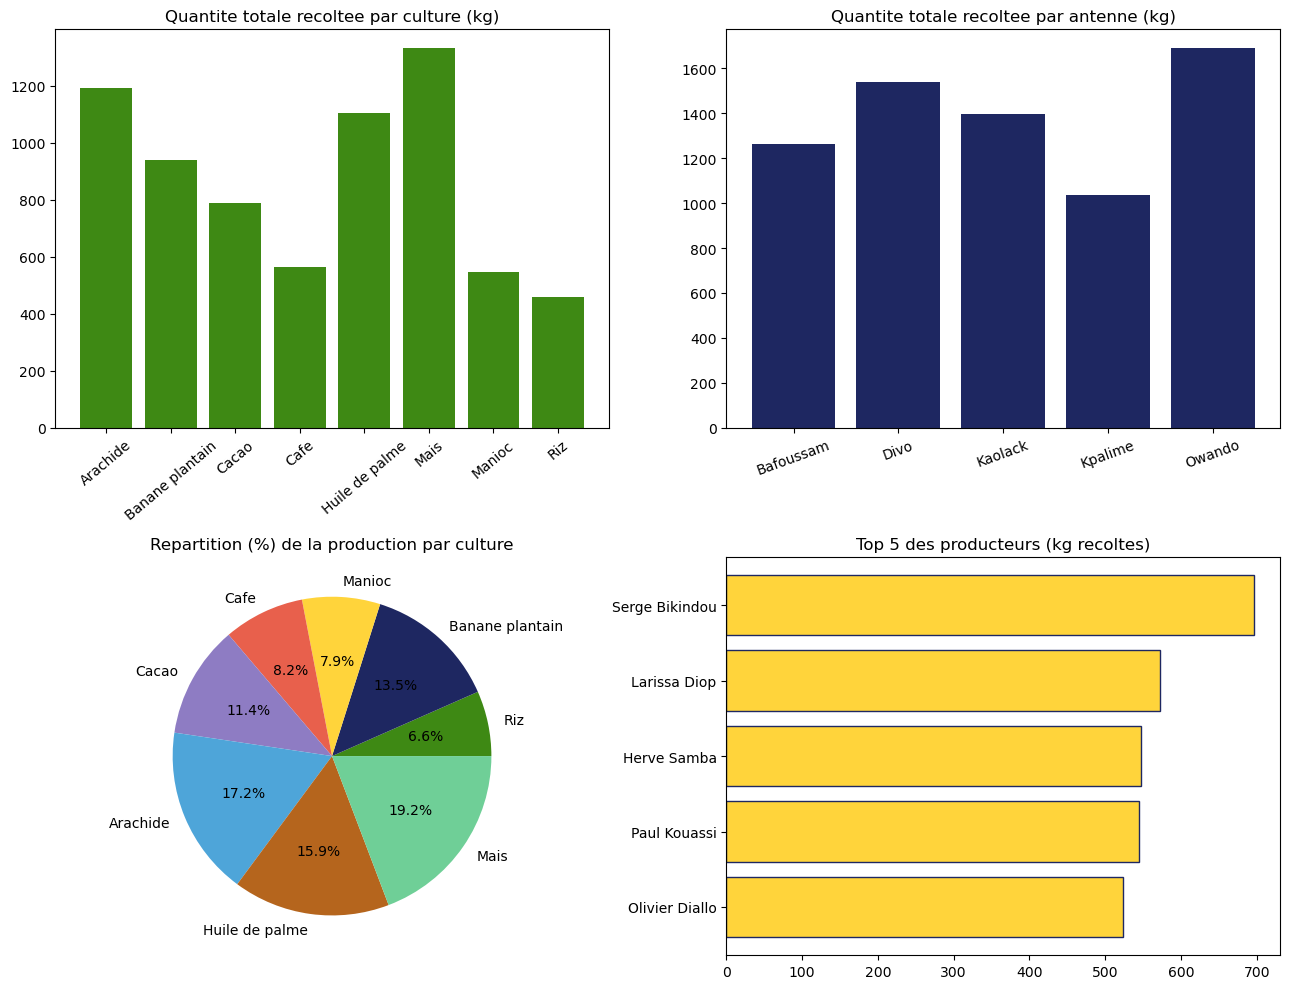

In [28]:
import matplotlib.pyplot as plt

NAVY = "#1E2761"
GREEN = "#3E8914"
YELLOW = "#FFD43B"
CORAL = "#E8604C"
plt.rcParams["font.family"] = "DejaVu Sans"

cultures_uniques, antennes_uniques = cultures_et_antennes_uniques(CULTURES, ANTENNES)

noms_cultures = sorted(cultures_uniques)
totaux_cultures = [quantite_totale_culture(CULTURES, QUANTITES_KG, c) for c in noms_cultures]

noms_antennes = sorted(antennes_uniques)
totaux_antennes = []
for antenne in noms_antennes:
    total_antenne = 0
    for i in range(len(ANTENNES)):
        if ANTENNES[i] == antenne and QUANTITES_KG[i] is not None:
            total_antenne += QUANTITES_KG[i]
    totaux_antennes.append(total_antenne)

repartition_pct = repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_uniques)
top5 = top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 5)
noms_top5 = [nom for nom, total in top5][::-1]
totaux_top5 = [total for nom, total in top5][::-1]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].bar(noms_cultures, totaux_cultures, color=GREEN)
axes[0, 0].set_title("Quantite totale recoltee par culture (kg)")
axes[0, 0].tick_params(axis="x", rotation=40)

axes[0, 1].bar(noms_antennes, totaux_antennes, color=NAVY)
axes[0, 1].set_title("Quantite totale recoltee par antenne (kg)")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].pie(
    repartition_pct.values(),
    labels=repartition_pct.keys(),
    autopct="%.1f%%",
    colors=[GREEN, NAVY, YELLOW, CORAL, "#8E7CC3", "#4EA5D9", "#B5651D", "#6FCF97"],
)
axes[1, 0].set_title("Repartition (%) de la production par culture")

axes[1, 1].barh(noms_top5, totaux_top5, color=YELLOW, edgecolor=NAVY)
axes[1, 1].set_title("Top 5 des producteurs (kg recoltes)")

plt.tight_layout()
plt.show()


---
## 9. Synthese *(a completer)*

Repondez en 3-4 phrases, en francais, directement dans cette cellule (double-cliquez pour
l'editer) :
- Quelle est la culture la plus rentable pour AgriSuds d'apres vos calculs ?
- Quelle antenne devrait, selon vous, recevoir un accompagnement prioritaire (prix bas,
  faible production...) ?
- Quelle a ete la fonction la plus difficile a ecrire, et pourquoi ?

*(Votre reponse ici)*


In [29]:
# ============================================================
# SYNTÈSE — Réponds en 3-4 phrases
# ============================================================

print("=== SYNTÈSE AGRI SUDS ===")

# 1. Chiffre d'affaires total
ca = chiffre_affaires_total(QUANTITES_KG, PRIX_KG_FCFA)
print(f"1. Chiffre d'affaires total : {ca:,.2f} FCFA")

# 2. Top producteur
top1 = top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 1)[0]
print(f"2. Producteur le plus productif : {top1[0]} ({top1[1]} kg)")

# 3. Répartition
cults, _ = cultures_et_antennes_uniques(CULTURES, ANTENNES)
repartition = repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cults)
culture_dominante = max(repartition, key=repartition.get)
print(f"3. Culture dominante : {culture_dominante} ({repartition[culture_dominante]}%)")

# 4. Données manquantes
nb_none = sum(1 for q in QUANTITES_KG if q is None)
print(f"4. Données manquantes : {nb_none} récoltes sur {len(QUANTITES_KG)}")

print("""
--- Écris ta synthèse ici (3-4 phrases) ---

Le chiffre d'affaires total généré par le réseau AgriSuds s'élève à X FCFA.
La culture dominante est le/la [culture] avec X% de la production totale.
Le producteur le plus productif est [nom] avec X kg récoltés.
Les fonctions ont géré les données manquantes (None) en les ignorant
dans les calculs, ce qui évite les erreurs et garantit des résultats fiables.
""")

=== SYNTÈSE AGRI SUDS ===
1. Chiffre d'affaires total : 4,503,616.60 FCFA
2. Producteur le plus productif : Serge Bikindou (695.9 kg)
3. Culture dominante : Mais (19.2%)
4. Données manquantes : 6 récoltes sur 50

--- Écris ta synthèse ici (3-4 phrases) ---

Le chiffre d'affaires total généré par le réseau AgriSuds s'élève à X FCFA.
La culture dominante est le/la [culture] avec X% de la production totale.
Le producteur le plus productif est [nom] avec X kg récoltés.
Les fonctions ont géré les données manquantes (None) en les ignorant
dans les calculs, ce qui évite les erreurs et garantit des résultats fiables.



---
## 10. Partagez votre projet sur LinkedIn

C'est l'occasion de montrer ce que vous savez faire ! Publiez un court post presentant ce
projet (le contexte AgriSuds, les notions utilisees, une capture d'ecran de vos graphiques),
en mentionnant Akieni Academy. N'hesitez pas a joindre votre notebook ou un lien vers votre
depot GitHub.
